## Interpretación del modelo seleccionado

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-25

### Description:

Análisis de las características del modelo `Ridge` seleccionado en la etapa anterior: qué atributos
usa y con qué peso, qué tipo de errores comete, a qué se deben esos errores y qué consecuencias
tienen. El objetivo es producir un listado fundamentado de pruebas y experimentos para la siguiente
iteración.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import ShuffleSplit, learning_curve, train_test_split

RANDOM_STATE = 42

## 💾 Load model and data

In [2]:
# resolve the project root by walking up until pyproject.toml is found,
# so the notebook works regardless of the directory Jupyter was launched from
PROJECT_DIR = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pyproject.toml").exists()
)
DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"

RUTA_MODELO = MODELS_DIR / "modelo-seleccion-admisiones.joblib"
modelo = joblib.load(RUTA_MODELO)
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['GRE Score','TOEFL Score','University Rating',...,'LOR ','CGPA', 'Research']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [3]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("sklearn version: ", sk.__version__)

Pandas version:  3.0.5
sklearn version:  1.9.0


El modelo **no se reentrena**: se carga el artefacto de la etapa anterior, lo que verifica de paso
que funciona fuera del notebook que lo creó.

La partición sí debe reconstruirse, y **debe ser idéntica** a la que se usó para seleccionarlo:
interpretar un modelo sobre un conjunto de prueba distinto describiría un modelo distinto. Se
reproducen por tanto la misma deduplicación y el mismo `random_state`.

In [4]:
admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
).drop_duplicates()

# rows repeating an earlier record while differing only in a missing value are not
# caught by drop_duplicates, because NaN is never equal to NaN
valores = admisiones_df.astype({c: "float64" for c in admisiones_df.columns}).to_numpy()
observados = ~np.isnan(valores)
duplicado = np.zeros(len(valores), dtype=bool)
for i in range(len(valores)):
    if duplicado[i]:
        continue
    ambos = observados[i] & observados[i + 1 :]
    igual = np.where(ambos, valores[i] == valores[i + 1 :], True).all(axis=1) & ambos.any(axis=1)
    duplicado[np.nonzero(igual)[0] + i + 1] = True

interpretacion_df = admisiones_df[~duplicado]

X_features = interpretacion_df.drop(columns=["Chance of Admit "])
Y_target = interpretacion_df["Chance of Admit "]
y_bins = pd.qcut(Y_target, q=5, labels=False, duplicates="drop")
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins
)

prediccion_test = modelo.predict(x_test)
residuos = y_test.to_numpy() - prediccion_test

print("Registros distintos:", len(interpretacion_df))
print("train:", x_train.shape, "| test:", x_test.shape)
print(f"MAE  : {mean_absolute_error(y_test, prediccion_test):.4f}")
print(f"RMSE : {root_mean_squared_error(y_test, prediccion_test):.4f}")
print(f"R2   : {r2_score(y_test, prediccion_test):.4f}")

Registros distintos: 400
train: (320, 7) | test: (80, 7)
MAE  : 0.0467
RMSE : 0.0722
R2   : 0.7496


## 🔎 Interpretación del modelo

`Ridge` es un modelo lineal: su predicción es una suma ponderada de los atributos más un intercepto.
Eso lo hace directamente interpretable, sin necesidad de herramientas de explicabilidad externas.

Los coeficientes se leen de dos formas complementarias:

- **Sobre atributos estandarizados**, que es como el modelo los ve. Son comparables entre sí y
  responden "¿qué atributo pesa más?".
- **En unidades originales**, dividiendo por la escala aprendida por el `StandardScaler`. Responden
  "¿cuánto cambia la predicción si este atributo sube un punto?", que es la pregunta que hace
  cualquier persona no técnica.

In [5]:
nombres_atributos = modelo.named_steps["preprocessor"].get_feature_names_out()
coeficientes = modelo.named_steps["model"].coef_
escalador = modelo.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]

# the binary branch is not scaled, so its scale is 1
escalas = np.append(escalador.scale_, 1.0)

coeficientes_df = pd.DataFrame(
    {
        "coef. estandarizado": coeficientes,
        "escala": escalas,
        "coef. unidades originales": coeficientes / escalas,
    },
    index=nombres_atributos,
).sort_values("coef. estandarizado", key=abs, ascending=False)

print(f"Intercepto: {modelo.named_steps['model'].intercept_:.4f}")
coeficientes_df.round(5)

Intercepto: 0.7149


,coef. estandarizado,escala,coef. unidades originales
numeric__CGPA,0.06418,0.59540,0.10779
numeric__GRE Score,0.02589,11.55773,0.00224
numeric__LOR,0.01938,0.90192,0.02149
binary__Research,0.01764,1.00000,0.01764
numeric__TOEFL Score,0.01722,6.08967,0.00283
numeric__University Rating,0.00643,1.14549,0.00561
numeric__SOP,0.00071,1.01939,0.00069


La segunda columna de coeficientes se lee así: **un punto más de `CGPA` aumenta la probabilidad
estimada de admisión en 10.8 puntos porcentuales**, mientras que un punto más de GRE la aumenta en
0.22. La diferencia de magnitud entre ambos no significa que GRE sea irrelevante, sino que sus
escalas son distintas: GRE se mueve en un rango de 50 puntos y CGPA en uno de 3.

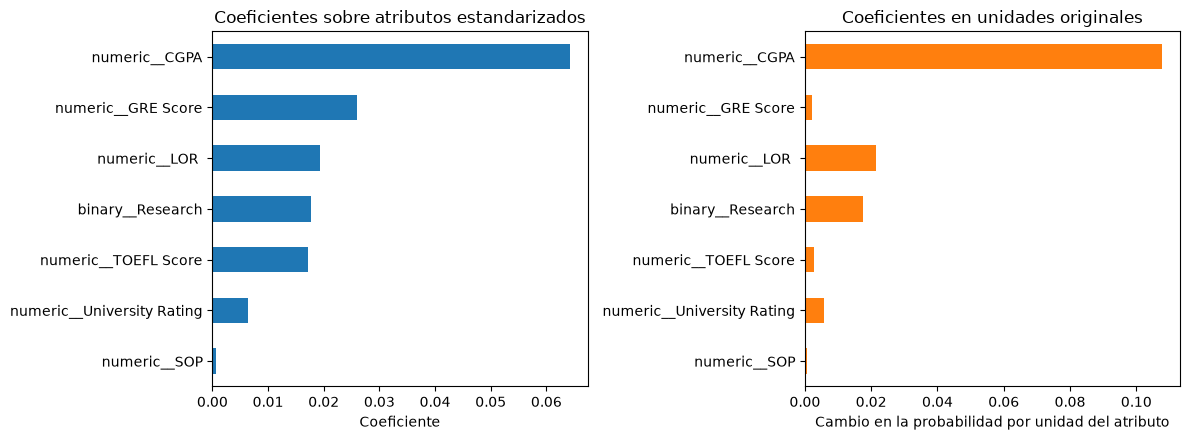

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

coeficientes_df["coef. estandarizado"].plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Coeficientes sobre atributos estandarizados")
axes[0].set_xlabel("Coeficiente")

coeficientes_df["coef. unidades originales"].plot(kind="barh", ax=axes[1], color="tab:orange")
axes[1].invert_yaxis()
axes[1].set_title("Coeficientes en unidades originales")
axes[1].set_xlabel("Cambio en la probabilidad por unidad del atributo")

fig.tight_layout()
plt.show()

### Identificación de los atributos más importantes

Los coeficientes indican cuánto pesa cada atributo **dentro de la fórmula**, pero no cuánto se
degrada el modelo si ese atributo desaparece. La importancia por permutación mide exactamente eso:
desordena los valores de una columna y observa cuánto empeora el error. Se calcula **sobre el
conjunto de prueba**, porque interesa la importancia para generalizar, no para ajustar.

In [7]:
# resolve the project root by walking up until pyproject.toml is found,
# so the notebook works regardless of the directory Jupyter was launched from
PROJECT_DIR = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pyproject.toml").exists()
)
DATA_DIR = PROJECT_DIR / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

In [8]:
importancia = permutation_importance(
    modelo,
    x_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

importancia_df = pd.DataFrame(
    {
        "importancia": importancia.importances_mean,
        "desviación": importancia.importances_std,
    },
    index=x_test.columns,
).sort_values("importancia", ascending=False)

importancia_df.round(5)

,importancia,desviación
CGPA,0.04229,0.00526
GRE Score,0.00910,0.00196
LOR,0.00661,0.00170
TOEFL Score,0.00482,0.00129
Research,0.00204,0.00107
University Rating,0.00076,0.00073
SOP,-0.00008,0.00008


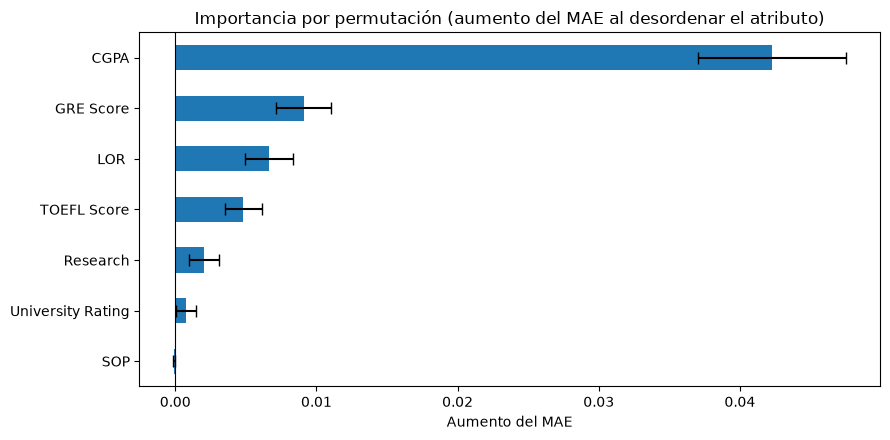

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
importancia_df["importancia"].plot(kind="barh", xerr=importancia_df["desviación"], ax=ax, capsize=4)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Importancia por permutación (aumento del MAE al desordenar el atributo)")
ax.set_xlabel("Aumento del MAE")
fig.tight_layout()
plt.show()

`CGPA` domina con claridad: desordenarlo multiplica el MAE por casi dos, y su importancia es 4.6
veces la del siguiente atributo. En el extremo opuesto, **`SOP` tiene importancia negativa**
(-0.00008): desordenarlo mejora marginalmente el modelo. No es un error de cálculo sino la firma de
un atributo que no aporta señal — el modelo funciona igual o mejor sin él.

Las tres lecturas disponibles coinciden en el orden: el coeficiente estandarizado, la importancia
por permutación y la correlación con el objetivo calculada en la etapa anterior sitúan a `CGPA`
primero y a `SOP` último.

### Dependencia parcial

Muestra cómo varía la predicción al recorrer el rango de un atributo, manteniendo el resto en sus
valores observados. En un modelo lineal estas curvas son rectas **por construcción**, y eso no es un
detalle estético: significa que el modelo asume que el efecto de cada atributo es constante en todo
su rango. Más adelante se comprueba si esa suposición se sostiene.

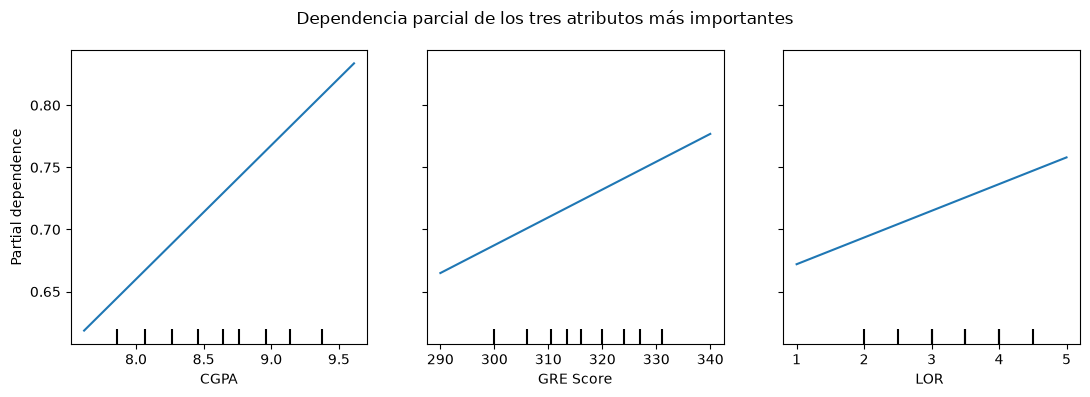

In [10]:
# partial dependence requires floating point columns, and the raw frame
# carries Int64 and boolean dtypes
x_train_pdp = x_train.astype(
    {columna: "float64" for columna in x_train.columns if x_train[columna].dtype != "float64"}
)

fig, ax = plt.subplots(figsize=(11, 4))
PartialDependenceDisplay.from_estimator(
    modelo, x_train_pdp, features=["CGPA", "GRE Score", "LOR "], ax=ax
)
fig.suptitle("Dependencia parcial de los tres atributos más importantes")
fig.tight_layout()
plt.show()

## 📈 Learning curve

Se repite el análisis sobre el modelo entregado para caracterizar su comportamiento con distintos
volúmenes de datos.

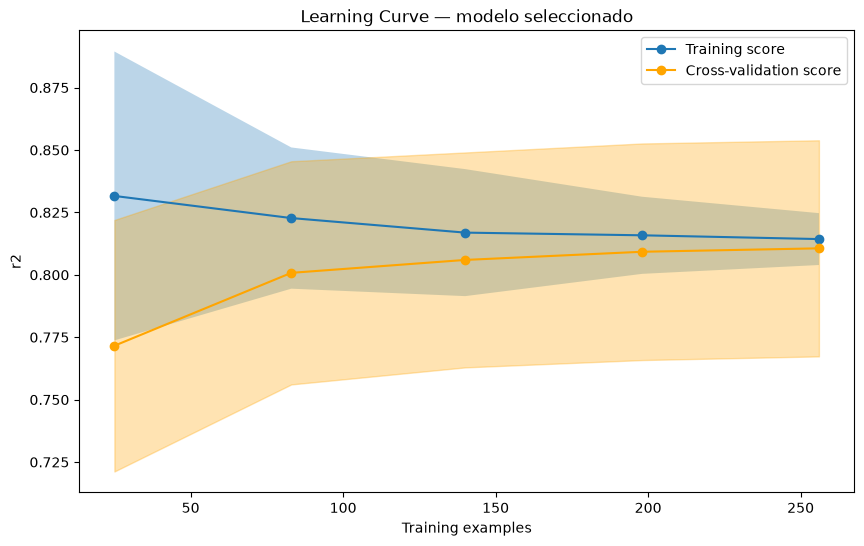

Training Sizes: [ 25  83 140 198 256]
Training Scores Mean: [0.8316 0.8227 0.8169 0.8158 0.8143]
Test Scores Mean:     [0.7716 0.8008 0.806  0.8092 0.8106]
Test Scores Std:      [0.0504 0.0447 0.0431 0.0434 0.0433]


In [11]:
parametros_curva = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    modelo, **parametros_curva, scoring="r2"
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)
fit_times_mean, fit_times_std = np.mean(fit_times, axis=1), np.std(fit_times, axis=1)
score_times_mean, score_times_std = (
    np.mean(score_times, axis=1),
    np.std(score_times, axis=1),
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")
ax.set_title("Learning Curve — modelo seleccionado")
ax.set_xlabel("Training examples")
ax.set_ylabel("r2")
ax.legend(loc="best")
plt.show()

print("Training Sizes:", train_sizes)
print("Training Scores Mean:", np.round(train_mean, 4))
print("Test Scores Mean:    ", np.round(test_mean, 4))
print("Test Scores Std:     ", np.round(test_std, 4))

### Escalabilidad

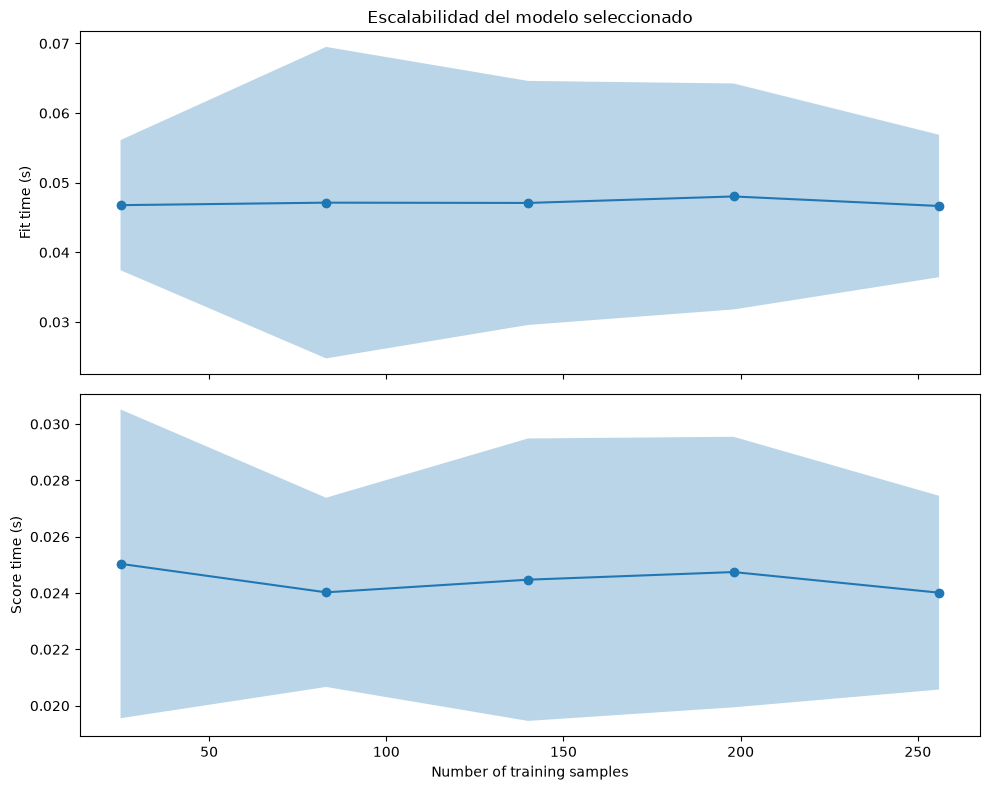

Fit Times Mean:   [0.04678 0.04714 0.0471  0.04803 0.04667]
Score Times Mean: [0.02504 0.02402 0.02447 0.02474 0.02401]


In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad del modelo seleccionado")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Number of training samples")

fig.tight_layout()
plt.show()

print("Fit Times Mean:  ", np.round(fit_times_mean, 5))
print("Score Times Mean:", np.round(score_times_mean, 5))

## ❌ ¿Qué tipo de errores comete el modelo?

Un MAE de 0.0467 dice cuánto se equivoca en promedio, pero no **dónde** ni **hacia dónde**. Esas dos
preguntas son las que importan para decidir si el modelo puede usarse.

In [13]:
UMBRAL_ERROR_MODERADO = 0.10
UMBRAL_ERROR_ALTO = 0.15

sobreestima = residuos < 0
subestima = residuos > 0

print(f"Residuo medio   : {residuos.mean():+.4f}")
print(f"Residuo mediano : {np.median(residuos):+.4f}")
print()
print(
    f"Sobreestima (predice de más): {sobreestima.sum():2d} de {len(residuos)} "
    f"({sobreestima.mean():.1%})  error medio = {np.abs(residuos[sobreestima]).mean():.4f}"
)
print(
    f"Subestima  (predice de menos): {subestima.sum():2d} de {len(residuos)} "
    f"({subestima.mean():.1%})  error medio = {np.abs(residuos[subestima]).mean():.4f}"
)
print()
print(
    f"Casos con error mayor a {UMBRAL_ERROR_MODERADO}: {(np.abs(residuos) > UMBRAL_ERROR_MODERADO).sum()}"
)
print(
    f"Casos con error mayor a {UMBRAL_ERROR_ALTO}: {(np.abs(residuos) > UMBRAL_ERROR_ALTO).sum()}"
)

Residuo medio   : -0.0098
Residuo mediano : +0.0084

Sobreestima (predice de más): 32 de 80 (40.0%)  error medio = 0.0706
Subestima  (predice de menos): 48 de 80 (60.0%)  error medio = 0.0307

Casos con error mayor a 0.1: 9
Casos con error mayor a 0.15: 5


El modelo sobreestima en el 40% de los casos y subestima en el 60%, pero **cuando sobreestima se
equivoca más del doble**: 0.0706 frente a 0.0307. El error no es simétrico.

In [14]:
errores_df = pd.DataFrame(
    {"real": y_test.to_numpy(), "predicción": prediccion_test, "residuo": residuos},
    index=x_test.index,
)
errores_df["error absoluto"] = errores_df["residuo"].abs()
errores_df["quintil real"] = pd.qcut(errores_df["real"], 5, labels=[f"Q{i}" for i in range(1, 6)])

por_quintil = errores_df.groupby("quintil real", observed=True).agg(
    n=("real", "size"),
    error_absoluto_medio=("error absoluto", "mean"),
    residuo_medio=("residuo", "mean"),
)
por_quintil.round(4)

,n,error_absoluto_medio,residuo_medio
quintil real,,,
Q1,16,0.1184,-0.0891
Q2,16,0.0342,-0.0065
Q3,16,0.0367,0.0197
Q4,17,0.0216,0.0145
Q5,15,0.0227,0.0123


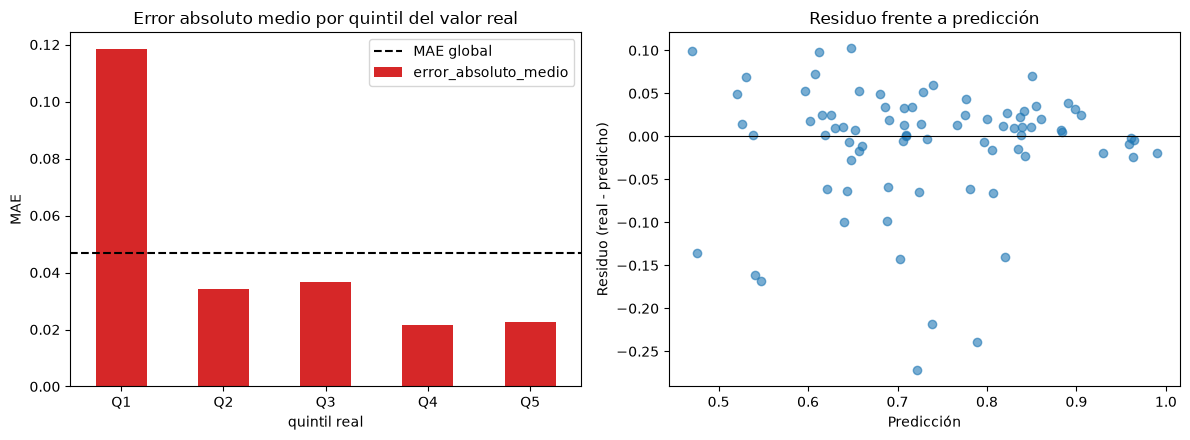

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

por_quintil["error_absoluto_medio"].plot(kind="bar", ax=axes[0], rot=0, color="tab:red")
axes[0].axhline(
    errores_df["error absoluto"].mean(),
    color="black",
    linestyle="--",
    label="MAE global",
)
axes[0].set_title("Error absoluto medio por quintil del valor real")
axes[0].set_ylabel("MAE")
axes[0].legend(loc="best")

axes[1].scatter(prediccion_test, residuos, alpha=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuo frente a predicción")

fig.tight_layout()
plt.show()

Aquí aparece el hallazgo central del análisis. **El error se concentra casi por completo en el
quintil inferior**: 0.1184 de error absoluto medio frente a 0.02–0.04 en los otros cuatro. Y el
residuo medio de ese quintil es -0.0891, es decir, el modelo **sobreestima sistemáticamente a los
candidatos con menor probabilidad real de admisión**.

Dicho de otro modo: el modelo funciona bien para quien tiene buenas opciones y falla justamente con
quien no las tiene, diciéndole que están mejor de lo que están.

In [16]:
peores = errores_df.join(x_test).sort_values("error absoluto", ascending=False).head(6)
peores.drop(columns=["quintil real"]).round(3)

,real,predicción,residuo,error absoluto,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
9,0.45,0.722,-0.272,0.272,323,108,3,3.5,3.0,8.60,False
65,0.55,0.789,-0.239,0.239,325,112,4,3.5,3.5,8.92,False
10,0.52,0.739,-0.219,0.219,325,106,3,3.5,4.0,8.40,True
91,0.38,0.548,-0.168,0.168,299,97,3,5.0,3.5,7.66,False
375,0.38,0.541,-0.161,0.161,304,101,2,2.0,2.5,7.66,False
63,0.56,0.703,-0.143,0.143,315,107,2,4.0,3.0,8.50,True


Las seis peores predicciones son **todas sobreestimaciones**, con valores reales entre 0.38 y 0.56.
No hay ni un solo caso extremo en el que el modelo se haya quedado corto.

## 🔬 ¿A qué se deben los errores?

Se examinan una por una las causas habituales, y se descartan con evidencia en lugar de por
suposición.

### ¿Valores atípicos?

Se aplica el criterio del rango intercuartílico sobre el conjunto de entrenamiento.

In [17]:
cols_numeric = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR ", "CGPA"]

atipicos = []
for columna in cols_numeric:
    serie = x_train[columna].astype("float64")
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    rango = q3 - q1
    inferior, superior = q1 - 1.5 * rango, q3 + 1.5 * rango
    atipicos.append(
        {
            "atributo": columna,
            "límite inferior": inferior,
            "límite superior": superior,
            "atípicos en train": int(((serie < inferior) | (serie > superior)).sum()),
        }
    )

pd.DataFrame(atipicos).set_index("atributo").round(2)

,límite inferior,límite superior,atípicos en train
atributo,,,
GRE Score,282.50,350.50,0
TOEFL Score,91.00,123.00,0
University Rating,-1.00,7.00,0
SOP,0.06,6.56,0
LOR,1.50,5.50,1
CGPA,6.83,10.36,1


Prácticamente no hay: un caso en `LOR ` y uno en `CGPA` sobre 320 filas. **Los valores atípicos no
explican los errores.**

Queda comprobar algo más específico: ¿son las peores predicciones perfiles atípicos? Se expresan sus
atributos en desviaciones respecto de la media de entrenamiento.

In [18]:
z_scores = (x_test.astype("float64") - x_train.astype("float64").mean()) / x_train.astype(
    "float64"
).std(ddof=1)

z_peores = z_scores.loc[peores.index]
print("Desviación máxima de cada perfil:", z_peores.abs().max(axis=1).round(2).to_list())
z_peores.round(2)

Desviación máxima de cada perfil: [1.06, 1.06, 0.94, 1.68, 1.57, 0.94]


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
9,0.56,0.12,-0.07,0.09,-0.48,0.00,-1.06
65,0.73,0.78,0.80,0.09,0.07,0.54,-1.06
10,0.73,-0.21,-0.07,0.09,0.63,-0.33,0.94
91,-1.51,-1.68,-0.07,1.56,0.07,-1.57,-1.06
375,-1.08,-1.03,-0.94,-1.38,-1.03,-1.57,-1.06
63,-0.13,-0.04,-0.94,0.58,-0.48,-0.16,0.94


Ninguno supera 1.7 desviaciones. **Son perfiles perfectamente ordinarios.** El modelo no falla ante
casos raros: falla ante candidatos de aspecto corriente cuyo resultado real fue mucho peor de lo que
su perfil sugiere. Esa es una pista fuerte sobre la causa verdadera.

### ¿Distribución desequilibrada del objetivo?

En regresión no existe el desbalance de clases, pero sí el equivalente: zonas del rango del objetivo
con muy pocas observaciones para aprender.

Observaciones de entrenamiento con objetivo < 0.50:  29 de 320 (9.1%)
Observaciones de entrenamiento con objetivo < 0.55:  41 de 320 (12.8%)
Observaciones de entrenamiento con objetivo < 0.60:  58 de 320 (18.1%)
Observaciones de entrenamiento con objetivo < 0.65:  89 de 320 (27.8%)

Asimetría del objetivo: -0.3534


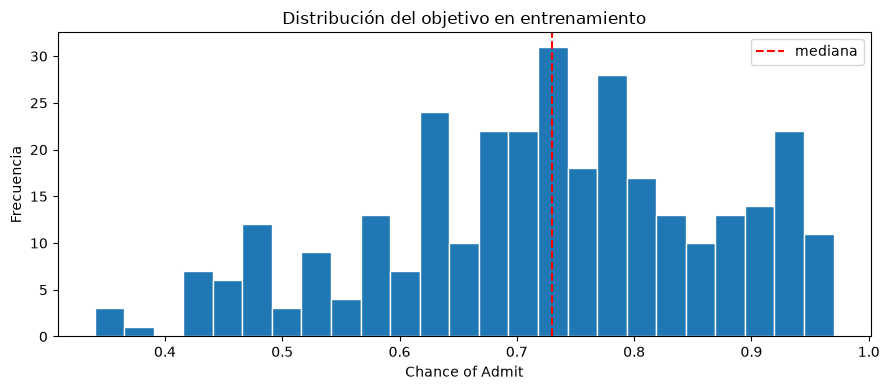

In [19]:
for umbral in [0.50, 0.55, 0.60, 0.65]:
    cantidad = int((y_train < umbral).sum())
    print(
        f"Observaciones de entrenamiento con objetivo < {umbral:.2f}: "
        f"{cantidad:3d} de {len(y_train)} ({cantidad / len(y_train):.1%})"
    )

print(f"\nAsimetría del objetivo: {Y_target.skew():+.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train, bins=25, edgecolor="white")
ax.axvline(y_train.median(), color="red", linestyle="--", label="mediana")
ax.set_xlabel("Chance of Admit")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del objetivo en entrenamiento")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

**Aquí sí hay una causa.** Solo el 9.1% de las observaciones de entrenamiento tiene una probabilidad
inferior a 0.5. El modelo dispone de muy poca señal en la zona donde precisamente falla.

### ¿El modelo comprime sus predicciones?

Un modelo que ajusta por mínimos cuadrados tiende a predecir valores menos extremos que los reales.
Se compara la dispersión de ambos.

In [20]:
ratio = prediccion_test.std(ddof=1) / y_test.std(ddof=1)

print(f"Desviación de los valores reales : {y_test.std(ddof=1):.4f}")
print(f"Desviación de las predicciones   : {prediccion_test.std(ddof=1):.4f}")
print(f"Ratio: {ratio:.3f}   (1.0 significaría ausencia de compresión)")
print()
print(f"Rango de los valores reales : [{y_test.min():.2f}, {y_test.max():.2f}]")
print(f"Rango de las predicciones   : [{prediccion_test.min():.2f}, {prediccion_test.max():.2f}]")

Desviación de los valores reales : 0.1451
Desviación de las predicciones   : 0.1240
Ratio: 0.855   (1.0 significaría ausencia de compresión)

Rango de los valores reales : [0.34, 0.97]
Rango de las predicciones   : [0.47, 0.99]


El modelo **no puede predecir por debajo de 0.47**, mientras que la realidad llega a 0.34. Es una
limitación estructural: por mucho que empeore el perfil de un candidato, la recta no baja lo
suficiente.

La sospecha inmediata es la regularización — `alpha=10` encoge los coeficientes y podría estar
comprimiendo el rango. Conviene comprobarlo en lugar de darlo por hecho.

In [21]:
transformador = modelo.named_steps["preprocessor"]
x_train_t, x_test_t = transformador.transform(x_train), transformador.transform(x_test)
quintil_bajo = (y_test <= y_test.quantile(0.2)).to_numpy()

efecto_alpha = []
for alpha in [0.1, 1.0, 10.0, 100.0]:
    candidato = Ridge(alpha=alpha, random_state=RANDOM_STATE).fit(x_train_t, y_train)
    prediccion = candidato.predict(x_test_t)
    efecto_alpha.append(
        {
            "alpha": alpha,
            "MAE global": mean_absolute_error(y_test, prediccion),
            "MAE quintil bajo": mean_absolute_error(y_test[quintil_bajo], prediccion[quintil_bajo]),
            "ratio de dispersión": prediccion.std(ddof=1) / y_test.std(ddof=1),
        }
    )

pd.DataFrame(efecto_alpha).set_index("alpha").round(4)

,MAE global,MAE quintil bajo,ratio de dispersión
alpha,,,
0.1,0.0468,0.1174,0.8679
1.0,0.0468,0.1175,0.8666
10.0,0.0467,0.1184,0.8548
100.0,0.0485,0.1221,0.7865


**La regularización no es la causa.** Con `alpha=0.1` —cien veces menor— el error en el quintil bajo
es 0.1174 frente a 0.1184, y el ratio de dispersión apenas pasa de 0.855 a 0.868. La compresión es
inherente al ajuste lineal, no a la penalización.

### ¿Un modelo no lineal resolvería el problema?

Si la causa fuera la forma funcional, un modelo capaz de curvarse debería mejorar en la zona
problemática.

In [22]:
bosque = RandomForestRegressor(
    random_state=RANDOM_STATE,
    max_depth=4,
    min_samples_leaf=4,
    max_features=0.6,
    n_estimators=200,
).fit(x_train_t, y_train)
prediccion_bosque = bosque.predict(x_test_t)

comparacion_familia = pd.DataFrame(
    [
        {
            "modelo": "Ridge (entregado)",
            "MAE global": mean_absolute_error(y_test, prediccion_test),
            "MAE quintil bajo": mean_absolute_error(
                y_test[quintil_bajo], prediccion_test[quintil_bajo]
            ),
        },
        {
            "modelo": "RandomForest",
            "MAE global": mean_absolute_error(y_test, prediccion_bosque),
            "MAE quintil bajo": mean_absolute_error(
                y_test[quintil_bajo], prediccion_bosque[quintil_bajo]
            ),
        },
    ]
).set_index("modelo")

comparacion_familia.round(4)

,MAE global,MAE quintil bajo
modelo,,
Ridge (entregado),0.0467,0.1184
RandomForest,0.0495,0.1136


Apenas mejora en el quintil bajo (0.1136 frente a 0.1184) y empeora en global. **Cambiar de familia
de modelo tampoco resuelve el problema**, lo que apunta a que la causa no está en el modelo sino en
los datos.

### ¿Errores en el ingreso de datos?

Se comprueban los dominios documentados en `data/01_raw/Informacion.txt`.

In [23]:
DOMINIOS = {
    "GRE Score": (260, 340),
    "TOEFL Score": (0, 120),
    "University Rating": (1, 5),
    "SOP": (1, 5),
    "LOR ": (1, 5),
    "CGPA": (0, 10),
    "Chance of Admit ": (0, 1),
}

violaciones = []
for columna, (inferior, superior) in DOMINIOS.items():
    serie = interpretacion_df[columna].astype("float64")
    violaciones.append(
        {
            "atributo": columna,
            "dominio": f"[{inferior}, {superior}]",
            "violaciones": int(((serie < inferior) | (serie > superior)).sum()),
        }
    )

pd.DataFrame(violaciones).set_index("atributo")

,dominio,violaciones
atributo,,
GRE Score,"[260, 340]",0
TOEFL Score,"[0, 120]",0
University Rating,"[1, 5]",0
SOP,"[1, 5]",0
LOR,"[1, 5]",0
CGPA,"[0, 10]",0
Chance of Admit,"[0, 1]",0


Cero violaciones. Sí existió un problema de calidad de datos —el archivo de partida contenía 223
filas duplicadas sobre 400 registros reales, corregido en una etapa anterior— pero los datos que
alimentan al modelo hoy respetan sus dominios. **No hay errores de ingreso que expliquen las
predicciones fallidas.**

### ¿Los codificadores?

`Research` es la única variable que pasa por un codificador. Se comprueba si concentra error.

In [24]:
errores_df["Research"] = x_test["Research"].astype("float64").to_numpy()
por_research = errores_df.groupby("Research", observed=True).agg(
    n=("real", "size"),
    error_absoluto_medio=("error absoluto", "mean"),
    residuo_medio=("residuo", "mean"),
)
por_research.round(4)

,n,error_absoluto_medio,residuo_medio
Research,,,
0.0,31,0.0580,-0.0212
1.0,49,0.0395,-0.0026


Hay diferencia —0.0580 de error en quienes no tienen experiencia investigadora frente a 0.0395 en
quienes sí— pero se explica por la composición: el grupo sin investigación concentra la mayoría de
los candidatos de baja probabilidad, que son los que el modelo predice mal. **El codificador no es
la causa**; la codificación ordinal 0/1 de una variable binaria no admite ambigüedad.

## ⚠️ ¿Cuáles son las consecuencias de las malas predicciones?

El modelo estima la probabilidad de que un candidato sea admitido en un programa de posgrado. Un
error tiene consecuencias distintas según su dirección.

**Sobreestimar** —decirle a alguien que tiene un 72% cuando en realidad tiene un 45%— lleva a esa
persona a postularse a programas fuera de su alcance, a pagar tasas de solicitud, a preparar
documentación y, sobre todo, a no considerar alternativas realistas. El coste es económico y de
oportunidad, y recae por completo sobre el candidato.

**Subestimar** lleva al efecto contrario: alguien renuncia a postularse a un programa al que habría
entrado. El coste es de oportunidad y, a diferencia del anterior, es invisible — nadie se entera de
la admisión que no solicitó.

Los dos importan, pero **el análisis de errores muestra que este modelo comete sistemáticamente el
primero**: sobreestima en el 40% de los casos con un error medio del doble, y esa sobreestimación se
concentra en el quintil de menor probabilidad real. El modelo es optimista precisamente con quienes
menos margen tienen.

Con un error absoluto máximo de 0.27 en el conjunto de prueba, un candidato con un 38% real puede
recibir una estimación del 55%. Si esa cifra se presentara como una recomendación automática, la
decisión resultante sería claramente perjudicial para esa persona.

## 🧪 Pruebas y experimentos para la siguiente iteración

Derivados directamente del diagnóstico anterior, ordenados por la evidencia que los respalda.

**1. Incorporar atributos que expliquen el extremo bajo.** Es el experimento con mayor respaldo: las
peores predicciones corresponden a perfiles ordinarios —ninguno supera 1.7 desviaciones— cuyo
resultado real fue mucho peor de lo que sus atributos sugieren. Eso significa que **la información
que explica esos rechazos no está en el conjunto de datos**. El análisis exploratorio ya identificó
candidatas: programa solicitado, institución de procedencia, cohorte y contenido real de las cartas
de recomendación.

**2. Modelar el objetivo transformado con la función logit.** El modelo no puede predecir por debajo
de 0.47 porque una recta no se aplana en los extremos de un intervalo acotado. Ajustar sobre
`log(p/(1-p))` y deshacer la transformación al predecir permite que la salida se comprima
naturalmente hacia 0 y 1, respetando la naturaleza del objetivo.

**3. Ponderar las observaciones del extremo bajo durante el entrenamiento.** Solo el 9.1% del
conjunto tiene un objetivo inferior a 0.5. Asignar mayor peso a esas filas mediante `sample_weight`
haría que el modelo pague un coste mayor por equivocarse ahí. Debe medirse si el precio en error
global es aceptable.

**4. Optimizar contra una métrica sensible al extremo.** El MAE promedia todos los errores por
igual, de modo que el 20% inferior queda diluido. Optimizar contra el MAE del quintil bajo, o contra
un error ponderado, alinearía el criterio de selección con el problema real.

**5. Eliminar `SOP` y verificar que el desempeño se sostiene.** Su importancia por permutación es
-0.00008, es decir, desordenarlo mejora marginalmente el modelo. Un predictor menos abarata el
mantenimiento y la explicación sin coste aparente.

**6. Reevaluar `Lasso` y `ElasticNet` con hiperparámetros optimizados.** Quedaron descartados en la
etapa anterior con `alpha=1.0` por defecto, valor que anulaba todos sus coeficientes. `Lasso` podría
además confirmar la irrelevancia de `SOP` llevándolo exactamente a cero.

**7. Probar modelos que respeten el rango [0, 1] por construcción**, como una regresión beta. Es una
alternativa a la transformación logit del punto 2, con la ventaja de modelar directamente la
naturaleza acotada del objetivo.

**8. Validación cruzada anidada.** Separa la optimización de hiperparámetros de la estimación de
desempeño y elimina el sesgo optimista que introduce elegir y medir sobre los mismos pliegues.

**9. Evaluar con validación cruzada estratificada por quintiles.** Garantizaría que cada pliegue
contenga observaciones del extremo bajo y que las métricas de validación reflejen el comportamiento
en esa zona.

**10. Ampliar el conjunto de prueba o sustituirlo por validación cruzada repetida.** Con 80
observaciones, el quintil inferior lo componen 16 casos; cualquier conclusión sobre esa zona se
apoya en una muestra muy reducida.

## 📊 Analysis of Results and Conclusions

**El modelo.** `Ridge` con `alpha=10`, cargado desde el artefacto `.joblib` de la etapa anterior sin
reentrenarlo. Reproduce exactamente las métricas reportadas entonces —MAE 0.0467, RMSE 0.0722,
R² 0.7496 sobre prueba— lo que confirma que el artefacto entregado es funcional fuera del notebook
que lo generó.

**Atributos más importantes.** Las tres lecturas disponibles coinciden en el orden. El coeficiente
estandarizado sitúa a `CGPA` en 0.0642, dos veces y media por encima de `GRE Score`. La importancia
por permutación sobre el conjunto de prueba es aún más contundente: desordenar `CGPA` aumenta el MAE
en 0.0423, **4.6 veces más que el siguiente atributo**.

| Atributo | Coef. estandarizado | Coef. unidades originales | Importancia por permutación |
|---|---|---|---|
| CGPA | 0.0642 | 0.1078 | 0.0423 |
| GRE Score | 0.0259 | 0.0022 | 0.0091 |
| LOR | 0.0194 | 0.0215 | 0.0066 |
| Research | 0.0176 | 0.0176 | 0.0020 |
| TOEFL Score | 0.0172 | 0.0028 | 0.0048 |
| University Rating | 0.0064 | 0.0056 | 0.0008 |
| SOP | 0.0007 | 0.0007 | **-0.0001** |

Los coeficientes en unidades originales son los que permiten explicar el modelo a alguien sin
formación técnica: **un punto más de CGPA equivale a 10.8 puntos porcentuales más de probabilidad
estimada de admisión**.

`SOP` merece mención aparte: su importancia por permutación es negativa. Desordenar sus valores
mejora marginalmente el modelo, que es la firma de un atributo sin señal. No es ruido de medición
—su desviación es 0.00008— sino evidencia de que la variable no aporta.

**Curva de aprendizaje y escalabilidad.** Entrenamiento y validación convergen con separación mínima,
y los tiempos de ajuste y predicción se mantienen constantes al crecer el conjunto. El modelo no
está limitado por volumen de datos ni por coste computacional.

**Tipo de errores.** Un MAE de 0.0467 describe el promedio, no la distribución. Al descomponerlo
aparecen dos asimetrías:

- **Por dirección**: el modelo sobreestima en el 40% de los casos y subestima en el 60%, pero cuando
  sobreestima se equivoca más del doble (0.0706 frente a 0.0307).
- **Por segmento**: el error absoluto medio del quintil inferior del objetivo es 0.1184, entre tres y
  seis veces el de los otros cuatro quintiles (0.0216 a 0.0367). El residuo medio de ese quintil es
  -0.0891, es decir, **sobreestimación sistemática**.

Las seis peores predicciones son todas sobreestimaciones, con valores reales entre 0.38 y 0.56. No
hay un solo caso extremo en el que el modelo se haya quedado corto. **El modelo funciona bien para
quien tiene buenas opciones y falla con quien no las tiene, diciéndole que está mejor de lo que
está.**

**Causas descartadas con evidencia.** Se examinaron una por una:

- *Valores atípicos*: dos casos sobre 320 filas de entrenamiento. Y más determinante: los perfiles de
  las peores predicciones no superan 1.7 desviaciones respecto de la media. **Son candidatos de
  aspecto perfectamente ordinario.**
- *Errores de ingreso de datos*: cero violaciones de dominio en las siete variables. Sí existió un
  problema de calidad —223 filas duplicadas sobre 400 registros reales— pero se corrigió en una
  etapa anterior.
- *Codificadores*: `Research` es la única variable codificada, y la diferencia de error entre sus dos
  grupos se explica por composición, no por la codificación. Una variable binaria llevada a 0/1 no
  admite ambigüedad.
- *Regularización*: era la sospecha natural, y los datos la desmienten. Con `alpha=0.1` —cien veces
  menor— el error del quintil bajo es 0.1174 frente a 0.1184, y el ratio de dispersión pasa de 0.855
  a 0.868. La compresión es inherente al ajuste lineal, no a la penalización.
- *Familia del modelo*: un `RandomForest` optimizado apenas mejora el quintil bajo (0.1136 frente a
  0.1184) y empeora en global. Cambiar de familia no resuelve el problema.

**Causas confirmadas.** Quedan tres, y se refuerzan entre sí:

1. **Escasez de datos en el extremo bajo.** Solo el 9.1% de las observaciones de entrenamiento tiene
   un objetivo inferior a 0.5. El modelo dispone de poca señal justo donde falla.
2. **Límite estructural del ajuste lineal.** Las predicciones no bajan de 0.47 mientras la realidad
   llega a 0.34, con un ratio de dispersión de 0.855. Una recta no se aplana en los extremos de un
   intervalo acotado.
3. **Información ausente.** Es la causa de fondo. Que las peores predicciones correspondan a perfiles
   ordinarios significa que **los atributos disponibles no contienen aquello que explica esos
   rechazos**. Dos candidatos con idénticos GRE, TOEFL, CGPA, SOP y LOR pueden tener resultados muy
   distintos por factores que el conjunto de datos no registra: el programa solicitado, la
   institución de procedencia, el contenido real de las cartas o la disponibilidad de financiación.

**Consecuencias.** Sobreestimar lleva a un candidato a postularse a programas fuera de su alcance,
con coste económico y de oportunidad que recae enteramente sobre él. Subestimar lleva a renunciar a
una admisión posible, con un coste invisible. Este modelo comete sistemáticamente el primero, y lo
comete con quienes menos margen tienen. Con un error absoluto máximo de 0.27, un candidato con un 38%
real puede recibir una estimación del 55%.

**Conclusión.** El modelo es adecuado como estimador global y su interpretación es transparente, pero
**no debe usarse como recomendación automática para candidatos de perfil bajo**. Su límite no está en
el algoritmo ni en los hiperparámetros —ambos descartados con evidencia— sino en los atributos
disponibles. La siguiente iteración debe orientarse a conseguir mejor información antes que a probar
modelos más complejos: el listado de experimentos de la sección anterior está ordenado con ese
criterio.

**Limitaciones del propio análisis.** El diagnóstico del quintil inferior se apoya en 16
observaciones del conjunto de prueba. Es suficiente para detectar un patrón tan marcado, pero no para
cuantificarlo con precisión. Las conclusiones sobre esa zona deberían revalidarse con validación
cruzada estratificada antes de tomar decisiones sobre ellas.

## 💡 Proposals and Ideas

Más allá del listado de experimentos, a nivel de proyecto:

- **Documentar el límite del modelo junto al modelo.** Cualquier consumidor del artefacto debería
  recibir, con él, la advertencia de que sobreestima sistemáticamente por debajo de 0.5. Un modelo
  entregado sin su diagnóstico de errores invita a usarlo donde no corresponde.
- **Definir un umbral operativo de confianza.** Si la predicción cae por debajo de 0.55, la salida
  debería marcarse como poco fiable y derivarse a revisión humana en lugar de presentarse como una
  cifra más.
- **Priorizar la recolección de atributos sobre la mejora algorítmica.** El análisis muestra que
  cambiar de modelo o de hiperparámetros no mueve la aguja en la zona problemática. El esfuerzo rinde
  más en conseguir programa solicitado, institución de procedencia y cohorte.
- **Registrar las métricas por segmento, no solo globales.** Un MAE agregado de 0.0467 ocultaba un
  error de 0.1184 en el quintil inferior. Cualquier tablero de seguimiento debería desglosar por
  quintil del objetivo.
- **Reevaluar el modelo si cambia la composición de los postulantes.** El diagnóstico depende de que
  el extremo bajo siga siendo minoritario. Si la distribución cambia, el comportamiento del modelo
  cambia con ella.
- **Considerar la interpretabilidad como criterio de selección explícito.** Este análisis fue posible
  en una tarde porque el modelo es lineal. Con un ensamble habría requerido herramientas adicionales
  y conclusiones menos directas, algo a ponderar antes de adoptar modelos más complejos en la
  siguiente iteración.

## 📖 References

- [Ciencia de datos con Python — Model Interpretation, José R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/)
- [scikit-learn — Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [scikit-learn — Partial dependence and individual conditional expectation](https://scikit-learn.org/stable/modules/partial_dependence.html)
- [scikit-learn — Linear models](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification)
- [scikit-learn — Common pitfalls in the interpretation of coefficients of linear models](https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html)